# Agentic AI - Tool Use Pattern
The agent leverages external functions (tools/APIs) to gather information or interact with the world outside its internal knowledge.

## Ollama Setup
So we will be using open source models from ollama as an llm/slm call to understand the concept

In [ ]:
%%capture
# let's download the ollama executables
!curl -fsSL https://ollama.com/install.sh | sh


In [ ]:
# serve the ollama
!nohup ollama serve &

In [ ]:
# pull the llm/slm models
# !ollama pull smollm:135m
# !ollama pull embeddinggemma:300m
# !ollama pull tinyllama:1.1b
# !ollama pull gemma3:270m
# !ollama pull gemma3:1b
!ollama pull llama3.2:1b


In [ ]:
# list the pulled models
!ollama list

## LangChain/LangGraph Framework
we will be using langchain framework to implement the agents

In [ ]:
# Installing required libraries
%%capture

!pip install langchain
!pip install langchain-ollama
!pip install langchain-core
!pip install langgraph
!pip install mermaid-py
!pip install pprintpp
!pip install wikipedia

In [ ]:

# importing required libs

from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.output_parsers import PydanticOutputParser
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import tool
from typing import TypedDict, Annotated
from IPython.display import Image
from pprint import pprint
import re
import random
import json
import operator

In [ ]:
llm = ChatOllama(model="llama3.2:1b") # using llama3.2:1b as this supports tool binding

### External function as a Tool
Creating a simple function which will be a tool for us and then we can use it in our flow to call it.

In [ ]:
# a tool can be anything, here let's say we are getting the order status from db

# Define the tool the agent can use
def get_order_status(user_query: str):
    """Fetches the status of a customer order from the database."""

    order_id_pattern = r"\b\d{5}\b"
    found_ids = re.findall(order_id_pattern, user_query)

    if len(found_ids) >= 1:
        return  " ".join([oid + " - "+random.choice(["Placed","Failed","Delievered", "Pending Confirmation"]) + "," for oid in found_ids])[:-1]
    else:
        return "System is unable to find order id"

# A node in the graph :
def order_agent_node(user_query:str):
    # We can include llm capabilities here too, which we will see later,
    result = get_order_status(user_query)
    return f"Here is the response for your order status query: {result}."


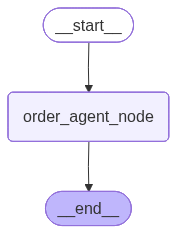

In [ ]:
# let's construct a graph and execute the flow
simpleToolGraph = (StateGraph(str)
.add_node(order_agent_node)
.add_edge(START, "order_agent_node")
.add_edge("order_agent_node", END)).compile()

Image(simpleToolGraph.get_graph().draw_mermaid_png())

In [ ]:
print(simpleToolGraph.invoke("Can I please get the order status for 1236587")) # invalid order id
print(simpleToolGraph.invoke("Can I please get the order status for 12365")) # single order id
print(simpleToolGraph.invoke("Hi, I have multiple order ids, can I please get the status for them: order ids: 12345, 58945, 25785, 2569845")) # multiple order id

Here is the response for your order status query: System is unable to find order id.
Here is the response for your order status query: 12365 - Pending Confirmation.
Here is the response for your order status query: 12345 - Placed, 58945 - Pending Confirmation, 25785 - Placed.


Perfect!!! Simple function call, let's see how it works with llm

### Tool integration with llm
So, here is the power of tools, we can bind them with llm such that we do not have to call them explicitly. We will let llm to determine if tool call needs to be happen and then we can call our function with required parameters (extracted by llm). Aamzing right 😀 let's see how it works.

In [ ]:
# creating function which will work as a tool
# decoration is required to make the function for llm binding tool
# Note: docstring is required to tell about the function as llm will understand the function purpose first and then add as a tool for further procesing
@tool
def do_multiply(num1: int, num2: int):
  """ Multiplies two numbers together and returns the outcome"""
  return num1 * num2

In [ ]:
# let's bind to our llm,
llm_with_multiply_tool = llm.bind_tools([do_multiply])

In [ ]:
# let's invoke the llm with user quety for multiplication
response = llm_with_multiply_tool.invoke("what is the result of 64*89?")

In [ ]:
# let's check the response
response

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2025-11-14T07:01:31.139578516Z', 'done': True, 'done_reason': 'stop', 'total_duration': 24640010619, 'load_duration': 10086761345, 'prompt_eval_count': 174, 'prompt_eval_duration': 9779139838, 'eval_count': 25, 'eval_duration': 4691689326, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--ea317b82-820d-46de-a6f8-84c9b48107a7-0', tool_calls=[{'name': 'do_multiply', 'args': {'num1': '64', 'num2': '89'}, 'id': '782b4db4-39c1-4e5f-8ec5-2b15aaa43412', 'type': 'tool_call'}], usage_metadata={'input_tokens': 174, 'output_tokens': 25, 'total_tokens': 199})

In [ ]:
# let's grab the section where it has tool_calls - this will tell if llm thinks, tool call need to be happen
decided_tool_calls = response.tool_calls
decided_tool_calls

[{'name': 'do_multiply',
  'args': {'num1': '64', 'num2': '89'},
  'id': '782b4db4-39c1-4e5f-8ec5-2b15aaa43412',
  'type': 'tool_call'}]

In [ ]:
# perfect lets loop and prepare of function run
call_do_multiply = None

for tool_call in decided_tool_calls:
  if tool_call["name"] == "do_multiply": # equals to our function name
    call_do_multiply = tool_call

if call_do_multiply is None:
  raise Exception("No tool calling has found.")

# so let's call the function with arguments extarcted by llm
final_result = do_multiply.invoke(call_do_multiply["args"])
print(final_result)

5696


😯 wow!!! it's super amazing to work with llm and tools 😀

### Tool integration with llm Agent
So, we saw tool functionality so far, now let's use it with agentic ai, to serve the purpose of learning for "tool use pattern"

**Use Case:** We will get the user query then, we will pass it to llm to determine the tool_calls and then we will produce final result

In [ ]:
# let's create a tool function

@tool
def do_wikipedia_summary(user_topic:str) -> str:
  """ Method performs wikipedia summary call to get the summary for the given topic"""
  try:
    return wikipedia.summary(user_topic, sentences=5)
  except Exception as e:
    return f"Exception from wiki summary: {str(e)}"

@tool
def do_wikipedia_search(user_topic:str) -> list:
  """ Method performs wikipedia result call to get the result for the given topic"""
  try:
      return wikipedia.search(user_topic, results=5)
  except Exception as e:
    return f"Exception from wiki search: {str(e)}"


In [ ]:

# let's create the agent node and state class

class ToolAgentState(TypedDict):
  wiki_search: list
  wiki_search_tool_call:dict
  wiki_summary:str
  wiki_summary_tool_call:dict
  user_topic:str
  user_query:str
  llm_response: AIMessage
  next_call: str
  final_response: str

# first let's bind the tool to our llm
llm_with_tools = llm.bind_tools([do_wikipedia_summary, do_wikipedia_search])

# creating llm agent node functionality
def llm_agent(toolAgentState:ToolAgentState):
  user_query = toolAgentState["user_query"]
  llm_response = llm_with_tools.invoke([HumanMessage(content=user_query)])
  return {"llm_response": llm_response}


# let's create another node to check the tool calls
def check_tool_calls(toolAgentState:ToolAgentState):
  tool_calls = toolAgentState["llm_response"].tool_calls
  output = { "next_call": "NO_TOOL"}
  if tool_calls:
    do_wiki_search = do_wiki_summary = False
    for tool_call in tool_calls:
      if tool_call["name"] == "do_wikipedia_summary":
        output["wiki_summary_tool_call"] = tool_call
        do_wiki_summary = True


      if tool_call["name"] == "do_wikipedia_search":
        output["wiki_search_tool_call"] = tool_call
        do_wiki_search = True


    if do_wiki_search and do_wiki_summary:
      output["next_call"] = "BOTH_TOOL"
      output["user_topic"]  = output["wiki_summary_tool_call"]["args"]["user_topic"]


    elif do_wiki_search:
      output["next_call"] = "WIKI_SEARCH_TOOL"
      output["user_topic"]  = output["wiki_search_tool_call"]["args"]["user_topic"]
    else:
      output["next_call"] = "WIKI_SUMMARY_TOOL"
      output["user_topic"]  = output["wiki_summary_tool_call"]["args"]["user_topic"]


  return output


# creating another node for invoking tool
def call_wiki_search(toolAgentState:ToolAgentState):
  wiki_search_tool_dict = toolAgentState["wiki_search_tool_call"]
  response = do_wikipedia_search.invoke(wiki_search_tool_dict["args"])
  return {"wiki_search": response}

# creating another node for invoking tool
def call_wiki_summary(toolAgentState:ToolAgentState):
  wiki_summary_tool_dict = toolAgentState["wiki_summary_tool_call"]
  response = do_wikipedia_summary.invoke(wiki_summary_tool_dict["args"])
  return {"wiki_summary": response}


# let's create the router to define the flow
def tool_router(toolAgentState:ToolAgentState):
  return toolAgentState["next_call"]


# creating another node to refine the output and prepare the final output
def prepare_response(toolAgentState:ToolAgentState):

  return {
      "final_response" : f"""
      Here is the response for your query:
      Topic: {toolAgentState['user_topic']}
      Wikipedia Summary: {toolAgentState['wiki_summary'] if 'wiki_summary' in toolAgentState and toolAgentState['wiki_summary'] else 'Not Asked'}
      Wikipedia Search: {toolAgentState['wiki_search'] if 'wiki_search' in toolAgentState and toolAgentState['wiki_search'] else 'Not Asked'}
      """
      }

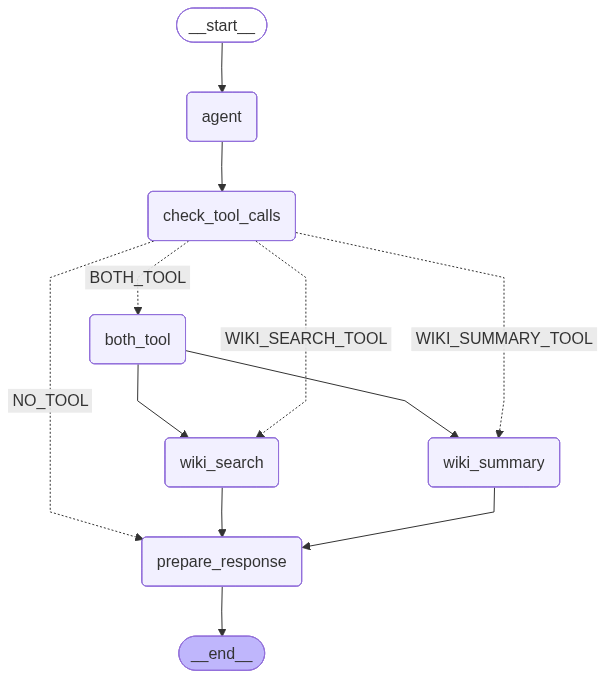

In [ ]:
# let's define the graph

agentToolGraph = StateGraph(ToolAgentState)

# adding nodes
agentToolGraph.add_node("agent", llm_agent)
agentToolGraph.add_node("check_tool_calls", check_tool_calls)
agentToolGraph.add_node("wiki_summary", call_wiki_summary)
agentToolGraph.add_node("wiki_search", call_wiki_search)
agentToolGraph.add_node("prepare_response", prepare_response)

# special node to execute both tools if required
agentToolGraph.add_node("both_tool", lambda state: state)

# adding edges
agentToolGraph.add_edge(START, "agent")
agentToolGraph.add_edge("agent", "check_tool_calls")

agentToolGraph.add_conditional_edges(
    "check_tool_calls",
    tool_router,
    {
        "NO_TOOL": "prepare_response",
        "WIKI_SEARCH_TOOL" : "wiki_search",
        "WIKI_SUMMARY_TOOL" : "wiki_summary",
        "BOTH_TOOL" : "both_tool"
    }
)


agentToolGraph.add_edge("both_tool", "wiki_summary")
agentToolGraph.add_edge("both_tool", "wiki_search")
agentToolGraph.add_edge("wiki_summary", "prepare_response")
agentToolGraph.add_edge("wiki_search", "prepare_response")
agentToolGraph.add_edge("prepare_response", END)


# let's compile the graph with checkpointer to check the state values later
agentToolWorkflow = agentToolGraph.compile(checkpointer=InMemorySaver())

Image(agentToolWorkflow.get_graph().draw_mermaid_png())


Let's execute and verify the implementation

In [ ]:
# let's define the config for checkpointers
config = {"configurable": {"thread_id": "th1"}}


In [ ]:
user_query_1 = "Can you please help me to get the wiki summary for topic langgraph?"
for chunk in agentToolWorkflow.stream({"user_query": user_query_1}, config=config): # default stream_mode is updates
  pprint(chunk)


{'agent': {'llm_response': AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2025-11-14T07:01:46.818875229Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14878544629, 'load_duration': 603950878, 'prompt_eval_count': 227, 'prompt_eval_duration': 11112999531, 'eval_count': 21, 'eval_duration': 3098426340, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--cee9acd4-5bc0-426c-aa59-1e6c9ba177a7-0', tool_calls=[{'name': 'do_wikipedia_summary', 'args': {'user_topic': 'langgraph'}, 'id': 'ac1f4c50-0a8c-4769-9f4b-647d159637c5', 'type': 'tool_call'}], usage_metadata={'input_tokens': 227, 'output_tokens': 21, 'total_tokens': 248})}}
{'check_tool_calls': {'next_call': 'WIKI_SUMMARY_TOOL',
                      'user_topic': 'langgraph',
                      'wiki_summary_tool_call': {'args': {'user_topic': 'langgraph'},
                                                 'id': 'ac1f4c50-0a8c-4769-9f4b

nice, it is identifying that I have asked for wiki summary

In [ ]:
user_query_2 = "Can you please help me to get the wiki summary and wiki search results for topic langgraph?"
for chunk in agentToolWorkflow.stream({"user_query": user_query_2}, config={"configurable": {"thread_id": "th2"}}): # default stream_mode is updates
  pprint(chunk)


{'agent': {'llm_response': AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2025-11-14T07:01:57.162794575Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9724719445, 'load_duration': 206480553, 'prompt_eval_count': 231, 'prompt_eval_duration': 709434529, 'eval_count': 52, 'eval_duration': 8650398004, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--142515b2-ec64-4729-9b4b-21387ab0ed27-0', tool_calls=[{'name': 'do_wikipedia_search', 'args': {'user_topic': 'langgraph'}, 'id': '00b3975b-aa5d-47d0-b4aa-849027a737a0', 'type': 'tool_call'}, {'name': 'do_wikipedia_summary', 'args': {'user_topic': 'langgraph'}, 'id': 'f6d9e4d9-7c3b-4b71-ba25-ce11fee7ee2b', 'type': 'tool_call'}], usage_metadata={'input_tokens': 231, 'output_tokens': 52, 'total_tokens': 283})}}
{'check_tool_calls': {'next_call': 'BOTH_TOOL',
                      'user_topic': 'langgraph',
                      'wiki_search_tool

wow!!! it is able to understand, that I have asked both operations

In [ ]:
user_query_3 = "Can you please help me to get the wiki summary and wiki search results for topic Microsoft?"
for chunk in agentToolWorkflow.stream({"user_query": user_query_3}, config={"configurable": {"thread_id": "th3"}}): # default stream_mode is updates
  pprint(chunk)


{'agent': {'llm_response': AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2025-11-14T07:02:08.492894603Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10980482745, 'load_duration': 212599798, 'prompt_eval_count': 230, 'prompt_eval_duration': 486688464, 'eval_count': 50, 'eval_duration': 10102078170, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--34b625d1-c916-43ae-939b-4cf8d523e657-0', tool_calls=[{'name': 'do_wikipedia_search', 'args': {'user_topic': 'Microsoft'}, 'id': '65567d7f-a742-4843-9a9e-1183a3c0c3f9', 'type': 'tool_call'}, {'name': 'do_wikipedia_summary', 'args': {'user_topic': 'Microsoft'}, 'id': 'd0cecd58-b9e1-4920-98e0-aed4327a0dd6', 'type': 'tool_call'}], usage_metadata={'input_tokens': 230, 'output_tokens': 50, 'total_tokens': 280})}}
{'check_tool_calls': {'next_call': 'BOTH_TOOL',
                      'user_topic': 'Microsoft',
                      'wiki_search_to

Finl output would look like this:



In [ ]:
user_query_4 = "Can you please help me to get the wiki summary and wiki search results for topic Python?"
response = agentToolWorkflow.invoke({"user_query": user_query_4}, config={"configurable": {"thread_id": "th4"}})
print(response['final_response'])




      Here is the response for your query:
      Topic: Python
      Wikipedia Summary: The Pythonidae, commonly known as pythons, are a family of nonvenomous  snakes found in Africa, Asia, and Australia. Among its members are some of the largest snakes in the world. Ten genera and 39 species are currently recognized. Being naturally non-venomous, pythons must constrict their prey to induce cardiac arrest prior to consumption. Pythons will typically strike at and bite their prey of choice to gain hold of it; they then must use physical strength to constrict their prey, by coiling their muscular bodies around the animal, effectively suffocating it before swallowing whole.
      Wikipedia Search: ['Python', 'Python (programming language)', 'Monty Python', 'Reticulated python', 'Python (codename)']
      


In [ ]:
# complete output
pprint(response)

{'final_response': '\n'
                   '      Here is the response for your query:\n'
                   '      Topic: Python\n'
                   '      Wikipedia Summary: The Pythonidae, commonly known as '
                   'pythons, are a family of nonvenomous  snakes found in '
                   'Africa, Asia, and Australia. Among its members are some of '
                   'the largest snakes in the world. Ten genera and 39 species '
                   'are currently recognized. Being naturally non-venomous, '
                   'pythons must constrict their prey to induce cardiac arrest '
                   'prior to consumption. Pythons will typically strike at and '
                   'bite their prey of choice to gain hold of it; they then '
                   'must use physical strength to constrict their prey, by '
                   'coiling their muscular bodies around the animal, '
                   'effectively suffocating it before swallowing whole.\n'
       

Nice, but is it not hectice to write so much of code, in case tools gets more and more then we would be writing so much code. Nope, langgraph has very useful feature "ToolNode" which enables self execution of tools

### Multi Tool with llm Agent

In [ ]:
from langgraph.prebuilt import ToolNode
import random

Let's solution this with more robust design

In [ ]:

class MultiToolAgentState(TypedDict):
  messages : Annotated[list[AIMessage | HumanMessage | ToolMessage], operator.add]

In [ ]:
# let's add another tool to make it little complex and interesting

@tool
def generate_random_number(lowerBoundary:int, upperBoundary: int):
  """ Generates random number between given boundaries"""
  return random.randint(lowerBoundary, upperBoundary)


In [ ]:
# creating list of all tools
multiTools = [do_multiply, do_wikipedia_search, do_wikipedia_summary, generate_random_number]

llm_with_multi_tools = ChatOllama(model="llama3.2:1b").bind_tools(multiTools)

# let's create the node for invoking llm with new state class
def invoke_llm_agent(multiToolAgentState:MultiToolAgentState):
  input_message = multiToolAgentState["messages"]
  llm_call_response = llm_with_multi_tools.invoke(input_message)
  return {"messages": [llm_call_response]}

# let's create ToolNode for desire tools
toolsNode = ToolNode(multiTools)

# adding router
def multi_tool_router(multiToolAgentState:MultiToolAgentState):
  # so the souce would be llm only thus we can use below
  llm_response = multiToolAgentState["messages"][-1]

  # checking if llm has tool calls
  #print("llm_response",llm_response)
  if llm_response.tool_calls:
    return "make_tool_call"
  else:
    return "end"


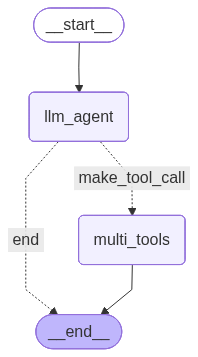

In [ ]:
# nice, let's define the graph

multiToolGraph = StateGraph(MultiToolAgentState)

# adding node
multiToolGraph.add_node("llm_agent", invoke_llm_agent)
multiToolGraph.add_node("multi_tools", toolsNode)

# adding edges
multiToolGraph.add_edge(START, "llm_agent")
multiToolGraph.add_conditional_edges(
    "llm_agent",
    multi_tool_router,
    {
        "make_tool_call": "multi_tools",
        "end": END
    }
)

# multiToolGraph.add_edge("multi_tools", "llm_agent")


# let's compile and visualize the graph
multiToolWorkflow = multiToolGraph.compile()
Image(multiToolWorkflow.get_graph().draw_mermaid_png())


nice, let's pass the input and see how it works

In [ ]:
# preparing input:
user_input = "Can you please help me to get the wiki summary and wiki search results for topic Python?"
inputs = {"messages": [HumanMessage(content=user_input)]}
for ochunk in multiToolWorkflow.stream(inputs):
  pprint(ochunk)


{'llm_agent': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2025-11-14T07:11:55.407861632Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8434769108, 'load_duration': 438360690, 'prompt_eval_count': 341, 'prompt_eval_duration': 1793124455, 'eval_count': 40, 'eval_duration': 6087944826, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--b10dd190-ccdf-4ffe-a291-2bdfc537cf76-0', tool_calls=[{'name': 'do_wikipedia_search', 'args': {'user_topic': 'Python'}, 'id': 'deb9be4d-46ac-4dc4-9bd1-7c90d4097c50', 'type': 'tool_call'}, {'name': 'do_wikipedia_summary', 'args': {'user_topic': 'Python'}, 'id': '281f3506-02b3-4552-be33-d192eb3cad9a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 341, 'output_tokens': 40, 'total_tokens': 381})]}}
{'multi_tools': {'messages': [ToolMessage(content='["Python", "Python (programming language)", "Monty Python", "Reticulated python", "Pytho

In [ ]:
# preparing input:
user_input = "Please generate random number for me between 5698 and 878482."
inputs = {"messages": [HumanMessage(content=user_input)]}
for ochunk in multiToolWorkflow.stream(inputs):
  pprint(ochunk)


{'llm_agent': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2025-11-14T07:20:48.24867206Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7036143406, 'load_duration': 774891363, 'prompt_eval_count': 338, 'prompt_eval_duration': 559203066, 'eval_count': 32, 'eval_duration': 5596259370, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--bd1bfb6c-a6aa-4fe7-947c-2f90f41d7514-0', tool_calls=[{'name': 'generate_random_number', 'args': {'lowerBoundary': '5698', 'upperBoundary': '878482'}, 'id': '5a93ffae-9b19-450e-906d-8c6bdc1bf11a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 338, 'output_tokens': 32, 'total_tokens': 370})]}}
{'multi_tools': {'messages': [ToolMessage(content='386251', name='generate_random_number', tool_call_id='5a93ffae-9b19-450e-906d-8c6bdc1bf11a')]}}


In [ ]:
# preparing input:
user_input = "Hi can you perform below operation for me: 1. Do wikipedia summary for topic Google. 2. Perform random number generation between 600 and 900. 3. Answer what is the 12*5?"
inputs = {"messages": [HumanMessage(content=user_input)]}
for ochunk in multiToolWorkflow.stream(inputs):
  pprint(ochunk)


{'llm_agent': {'messages': [AIMessage(content='{\n\n"do_wikipedia_summary": "The Wikipedia article on \'Google\' has a summary about its origin, history, and impact.",\n\n"generate_random_number": {\n"lowerBoundary": 0,\n"upperBoundary": 900\n}\n\n,"do_multiply": {\n"num1": 12,\n"num2": 5\n}', additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2025-11-14T07:28:57.62758244Z', 'done': True, 'done_reason': 'stop', 'total_duration': 28177515004, 'load_duration': 449758696, 'prompt_eval_count': 368, 'prompt_eval_duration': 16043865312, 'eval_count': 70, 'eval_duration': 11466139164, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--5e5dc33e-66d8-454f-b642-41ca4aa9ebcd-0', usage_metadata={'input_tokens': 368, 'output_tokens': 70, 'total_tokens': 438})]}}


So, here we see, llm is not able to understand the request precisely. So here we can do to get the better results:



1.   Use the LLM which can understand/tackle the user input and determine the tool calls.

2.   We could also loop after tool calls to let the llm to reprocess the request. Loop & Reflection pattern. In above case we can uncomment this line and make it in loop: # multiToolGraph.add_edge("multi_tools", "llm_agent")

3.   we can manually call the tool if its critical to perform.

